# Advanced Data Visualization with Seaborn

This notebook explores advanced visualization techniques using the Seaborn library. Seaborn is built on top of Matplotlib and provides a high-level interface for drawing attractive and informative statistical graphics.

## Objectives:
- Master **Categorical Plots** (Scatter, Distribution, and Estimate plots).
- Understand the difference between **Axes-level** and **Figure-level** functions.
- Learn **Multi-plot grids** for complex data relationships (FacetGrid, PairGrid, JointGrid).
- Apply **Regression Plots** to visualize statistical relationships.


In [1]:
# Standard Imports
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set the theme for all plots
sns.set_theme(style="whitegrid")


In [2]:
# Loading Built-in Datasets from Seaborn
# These datasets are commonly used for demonstrating Seaborn's capabilities.

tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')
planets = sns.load_dataset('planets')

# Creating a Custom DataFrame for more clarity
custom_data = pd.DataFrame({
    'Student': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace'],
    'Score': [85, 92, 78, 95, 88, 82, 91],
    'Attendance': [95, 98, 85, 100, 92, 88, 96],
    'Category': ['A', 'A', 'B', 'A', 'B', 'B', 'A']
})

print("Tips Dataset Head:")
print(tips.head())
print("\nIris Dataset Head:")
print(iris.head())


Tips Dataset Head:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Iris Dataset Head:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


## Part 1: Categorical Plots

Seaborn categorizes its plotting functions into categories for easier access. The main categories for categorical data are:

### 1.1 Categorical Scatter Plots
- **Stripplot (`sns.stripplot`)**: Plots all data points along one of the axes.
- **Swarmplot (`sns.swarmplot`)**: Similar to a stripplot, but points are adjusted so they don't overlap, providing a better representation of distribution.

### 1.2 Categorical Distribution Plots
- **Boxplot (`sns.boxplot`)**: Visualizes data distribution through five-number summaries and outliers.
- **Violinplot (`sns.violinplot`)**: Combines boxplots with kernel density estimation (KDE).

### 1.3 Categorical Estimate Plots (Central Tendency)
- **Barplot (`sns.barplot`)**: Estimates central tendency (usually mean) with confidence intervals.
- **Pointplot (`sns.pointplot`)**: Connects points marking central tendency estimates.
- **Countplot (`sns.countplot`)**: Displays the number of observations in each category (similar to a histogram for categorical data).

### 1.4 Figure-level Function: `catplot()`
Seaborn provides `catplot()` as a high-level function that provides access to all these axes-level functions. By changing the `kind` parameter, you can switch between all the category types.


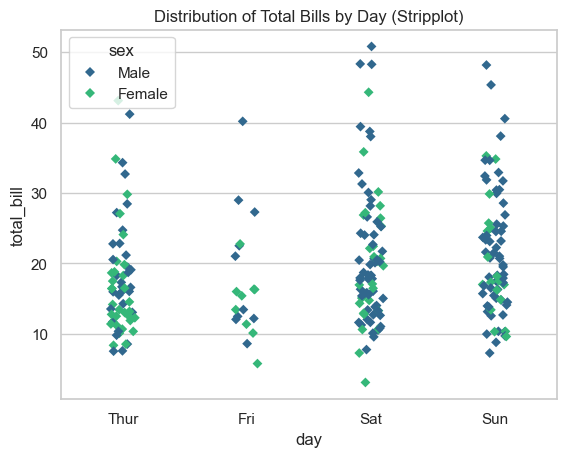

In [3]:
# Stripplot: Simple categorical scatter plot
# Using axes-level function: sns.stripplot
sns.stripplot(data=tips, x='day', y='total_bill', hue='sex', palette='viridis', marker='D', size=5)
plt.title('Distribution of Total Bills by Day (Stripplot)')
plt.show()


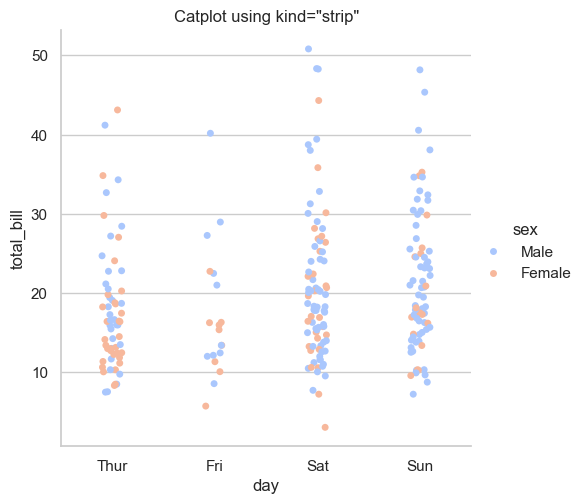

In [4]:
# Catplot: Figure-level function for categorical scatter plots
# Replacing sns.stripplot with sns.catplot(kind='strip')
sns.catplot(data=tips, x='day', y='total_bill', kind='strip', hue='sex', palette='coolwarm')
plt.title('Catplot using kind="strip"')
plt.show()


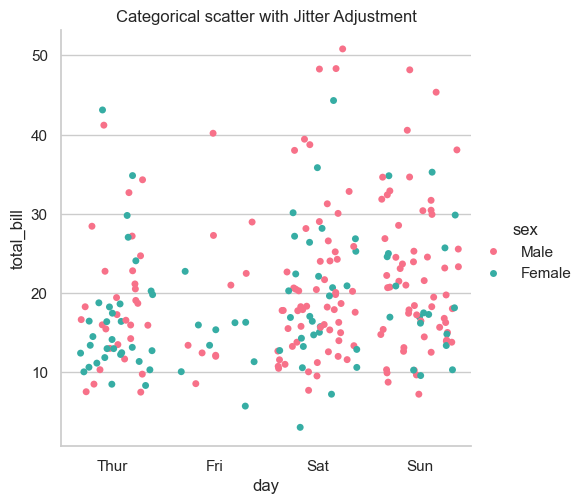

In [5]:
# Jitter: Adding randomness to avoid overlapping points in Stripplot
# Replacing kind='strip' with jitter customization
sns.catplot(data=tips, x='day', y='total_bill', kind='strip', jitter=0.4, hue='sex', palette='husl')
plt.title('Categorical scatter with Jitter Adjustment')
plt.show()


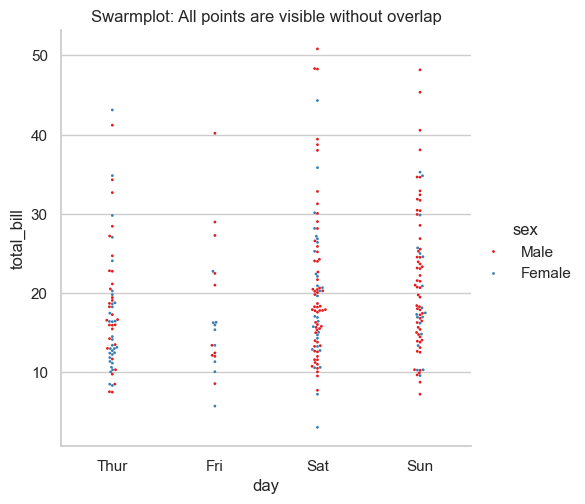

In [6]:
# Swarmplot: Avoiding overlapping points entirely
# kind='swarm' ensures that points are spread out for dense data.
sns.catplot(data=tips, x='day', y='total_bill', kind='swarm', hue='sex', palette='Set1', s=4)
plt.title('Swarmplot: All points are visible without overlap')
plt.show()


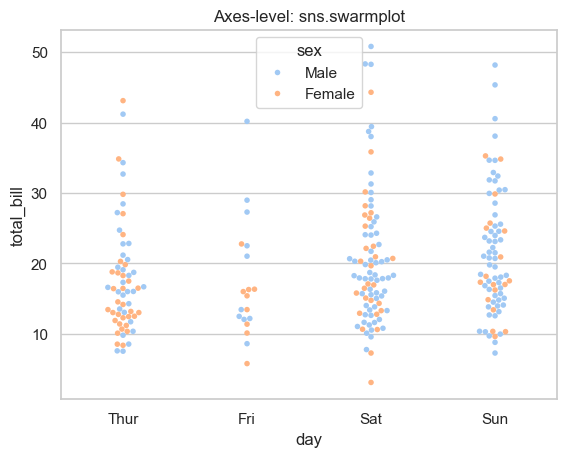

In [7]:
# Using Axes-level sns.swarmplot
# For direct control on specific axes
sns.swarmplot(data=tips, x='day', y='total_bill', palette='pastel', hue='sex', size=4)
plt.title('Axes-level: sns.swarmplot')
plt.show()


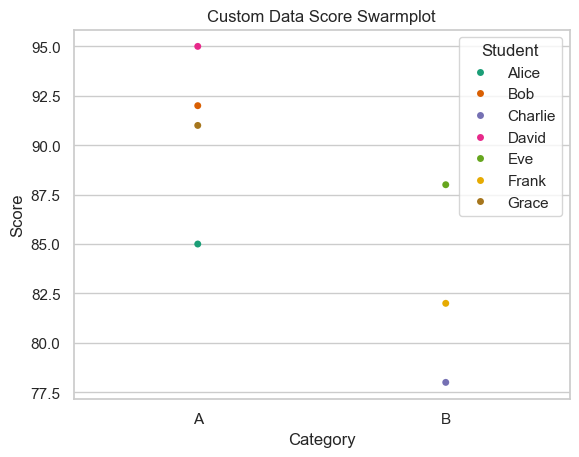

In [8]:
# Visualization with Custom Data (Pandas DataFrame)
# Illustrating complex categorical scenarios with clear custom data
sns.swarmplot(data=custom_data, x='Category', y='Score', hue='Student', palette='Dark2')
plt.title('Custom Data Score Swarmplot')
plt.show()


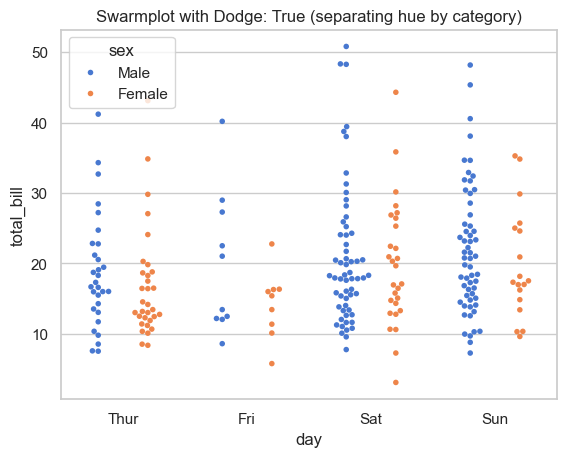

In [9]:
# Using sns.swarmplot with additional parameters: dodge=True (for better Hue comparison)
# This separates categorical groupings for easier visualization
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex', palette='muted', dodge=True, size=4)
plt.title('Swarmplot with Dodge: True (separating hue by category)')
plt.show()


### 1.2 Categorical Distribution: Boxplots & Violin Plots

#### **Boxplot (`sns.boxplot`)**
A boxplot is a standardized way of displaying the distribution of data based on a five-number summary:
1. **Minimum** (Smallest value, excluding outliers)
2. **First Quartile (Q1)** (25th percentile)
3. **Median** (50th percentile)
4. **Third Quartile (Q3)** (75th percentile)
5. **Maximum** (Largest value, excluding outliers)

It highlights **Outliers** and identifies **Skewness** and **Symmetry** in the data.

#### **Violinplot (`sns.violinplot`)**
A violinplot combines a boxplot and a Kernel Density Plot (KDE). It shows the distribution shapes of the data and helps identify multiple peaks (multimodality).


C:\Users\gaura\AppData\Local\Temp\ipykernel_19288\507800994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='total_bill', palette='Set3', whis=1.5, width=0.6)


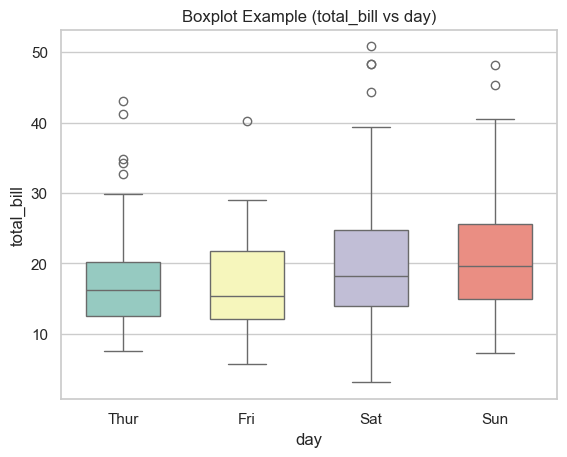

In [10]:
# Box plot: Standard distribution visualization
# Using sns.boxplot with customization
sns.boxplot(data=tips, x='day', y='total_bill', palette='Set3', whis=1.5, width=0.6)
plt.title('Boxplot Example (total_bill vs day)')
plt.show()


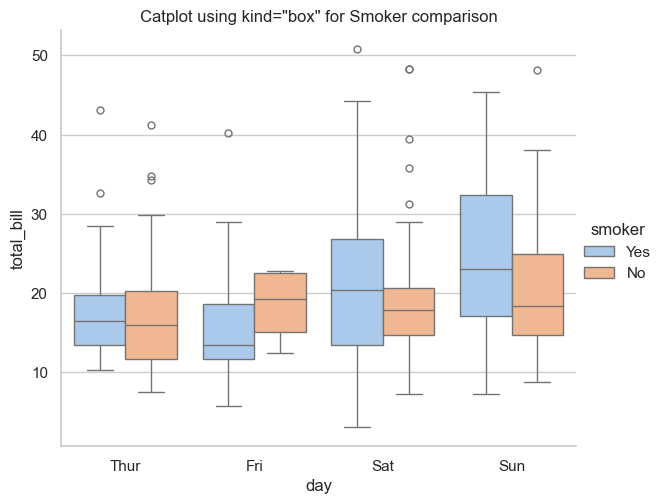

In [11]:
# Using catplot for Figures with kind="box"
# catplot is a more robust way to handle figure-level visualizations
sns.catplot(data=tips, x='day', y='total_bill', kind='box', hue='smoker', palette='pastel', height=5, aspect=1.2)
plt.title('Catplot using kind="box" for Smoker comparison')
plt.show()


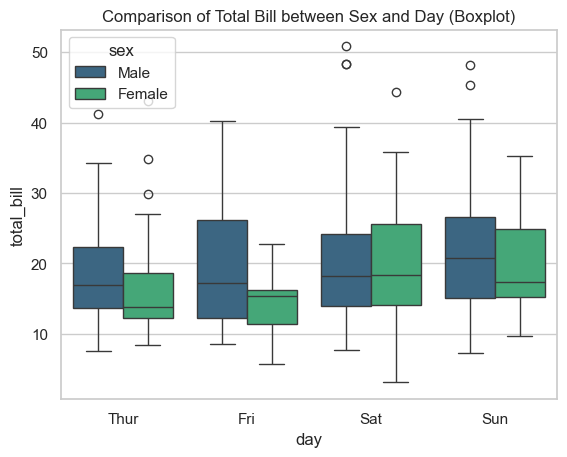

In [12]:
# Hue and dodging for Comparison in Boxplots
# Here we can see how smokers compare with non-smokers relative to each day
sns.boxplot(data=tips, x='day', y='total_bill', hue='sex', palette='viridis', dodge=True)
plt.title('Comparison of Total Bill between Sex and Day (Boxplot)')
plt.show()


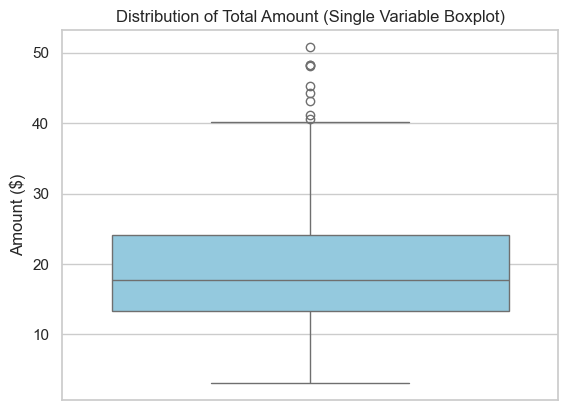

In [13]:
# Single boxplot for numerical data
# Visualizing the distribution of tip amount overall
sns.boxplot(y=tips['total_bill'], color='skyblue')
plt.ylabel('Amount ($)')
plt.title('Distribution of Total Amount (Single Variable Boxplot)')
plt.show()


### 1.2.2 Violin Plots
Violinplots combine a boxplot with a KDE (Kernel Density Ensemble), providing more detailed information about distribution shape.


C:\Users\gaura\AppData\Local\Temp\ipykernel_19288\117904530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x='day', y='total_bill', palette='husl', inner='quartile')


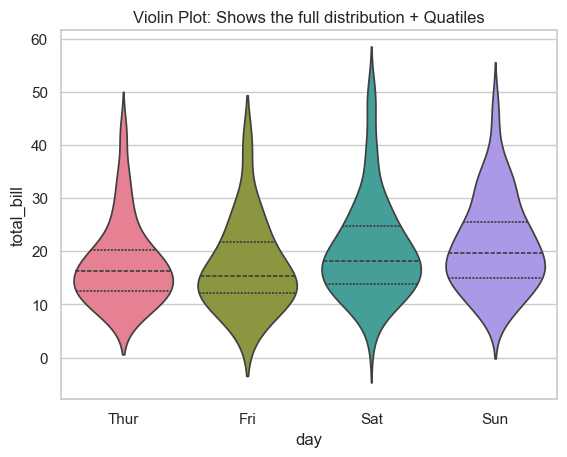

In [14]:
# Basic Violin Plot
# Using sns.violinplot
sns.violinplot(data=tips, x='day', y='total_bill', palette='husl', inner='quartile')
plt.title('Violin Plot: Shows the full distribution + Quatiles')
plt.show()


C:\Users\gaura\AppData\Local\Temp\ipykernel_19288\984517880.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=tips, x='day', y='total_bill', kind='violin', palette='flare')


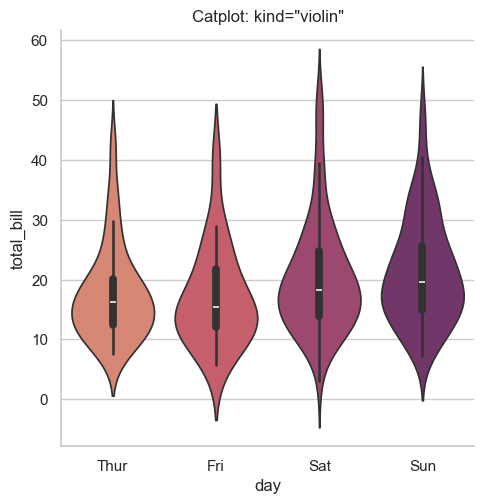

In [15]:
# Catplot: Figure-level for Violin Plots
# Replacing sns.violinplot with sns.catplot(kind='violin')
sns.catplot(data=tips, x='day', y='total_bill', kind='violin', palette='flare')
plt.title('Catplot: kind="violin"')
plt.show()


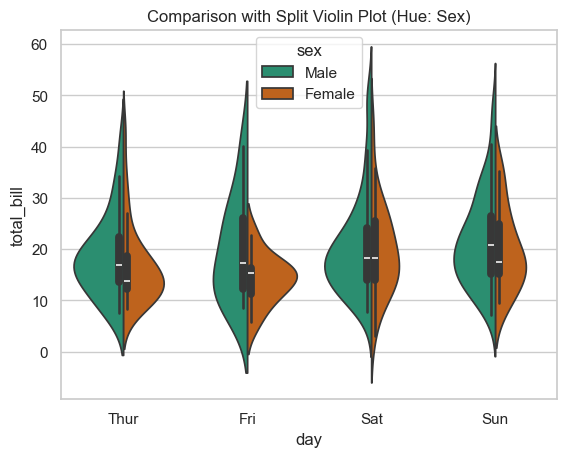

In [ ]:
# Using split=True with Violin Plots for Comparison
# split=True connects two separate distributions into a single violin
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex', split=True, palette='Dark2')
plt.title('Comparison with Split Violin Plot (Hue: Sex)')
plt.show()


# barplot

<Axes: xlabel='sex', ylabel='total_bill'>

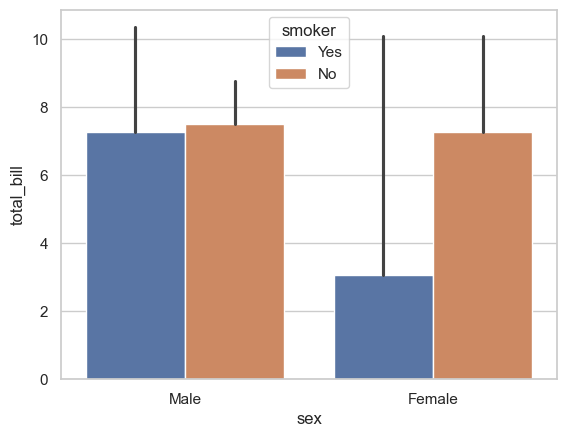

In [18]:
# some issue with errorbar
import numpy as np
sns.barplot(data=tips, x='sex', y='total_bill',hue='smoker',estimator=np.min)

C:\Users\gaura\AppData\Local\Temp\ipykernel_19288\2444887299.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=tips, x='sex', y='total_bill', ci=None, estimator=np.median, palette='viridis')
C:\Users\gaura\AppData\Local\Temp\ipykernel_19288\2444887299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='sex', y='total_bill', ci=None, estimator=np.median, palette='viridis')


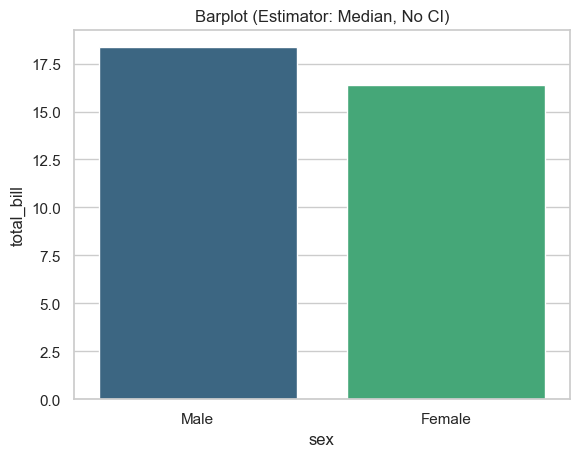

In [19]:
# Estimator and Confidence Interval Customization
# We can change the estimator or disable CI (ci=None)
sns.barplot(data=tips, x='sex', y='total_bill', ci=None, estimator=np.median, palette='viridis')
plt.title('Barplot (Estimator: Median, No CI)')
plt.show()


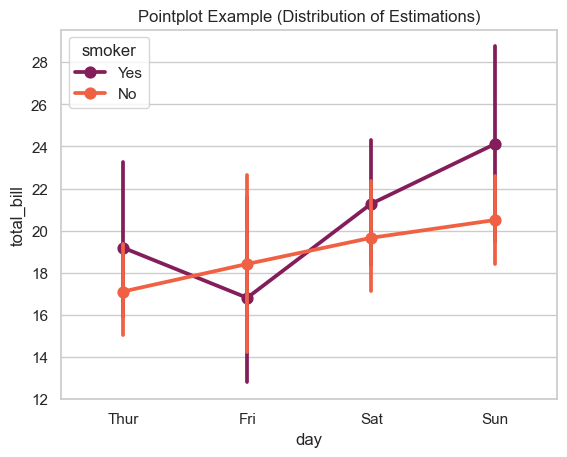

In [20]:
# Point Plots: Showing Estimate Trends
# Connects point estimates of central tendency across categories
sns.pointplot(data=tips, x='day', y='total_bill', hue='smoker', palette='rocket')
plt.title('Pointplot Example (Distribution of Estimations)')
plt.show()


### 1.3.1 Confidence Interval (CI) in Categorical Plots
When there are multiple observations in each category, Seaborn uses **bootstrapping** (sampling with replacement) to compute a confidence interval around the estimate (95% CI by default). This is plotted as error bars on the graph, indicating the uncertainty of our estimate.


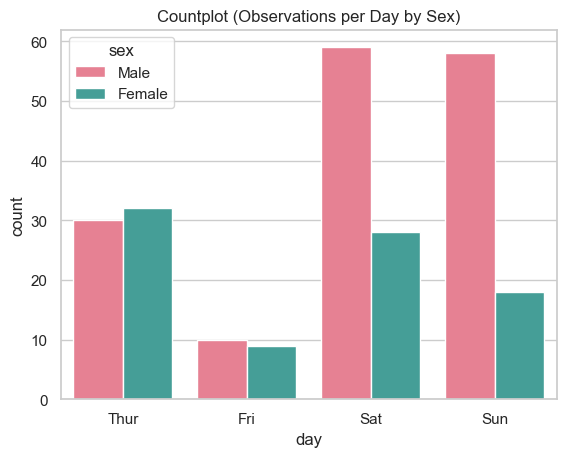

In [21]:
# Countplot: Frequency distribution
# Used when you want to show the number of observations in each category
sns.countplot(data=tips, x='day', hue='sex', palette='husl')
plt.title('Countplot (Observations per Day by Sex)')
plt.show()


### Countplot: A Special Case
A special case for the bar plot is when you want to show the **number of observations** in each category rather than computing a statistic for a second variable. This is similar to a histogram for categorical data.


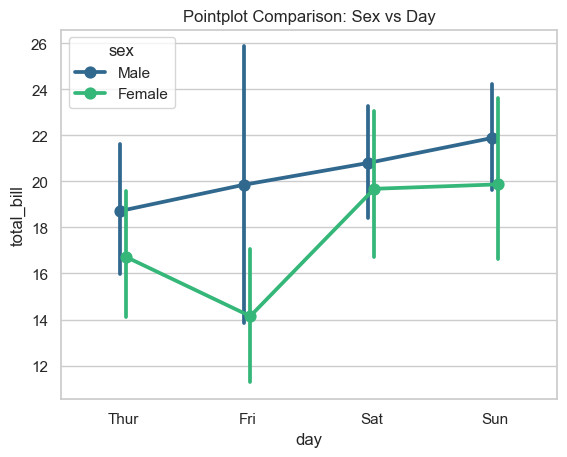

In [22]:
# Point Plots for Comparison and Estimation
# Connecting point estimates to highlight trends across categories
sns.pointplot(data=tips, x='day', y='total_bill', hue='sex', palette='viridis', dodge=True)
plt.title('Pointplot Comparison: Sex vs Day')
plt.show()


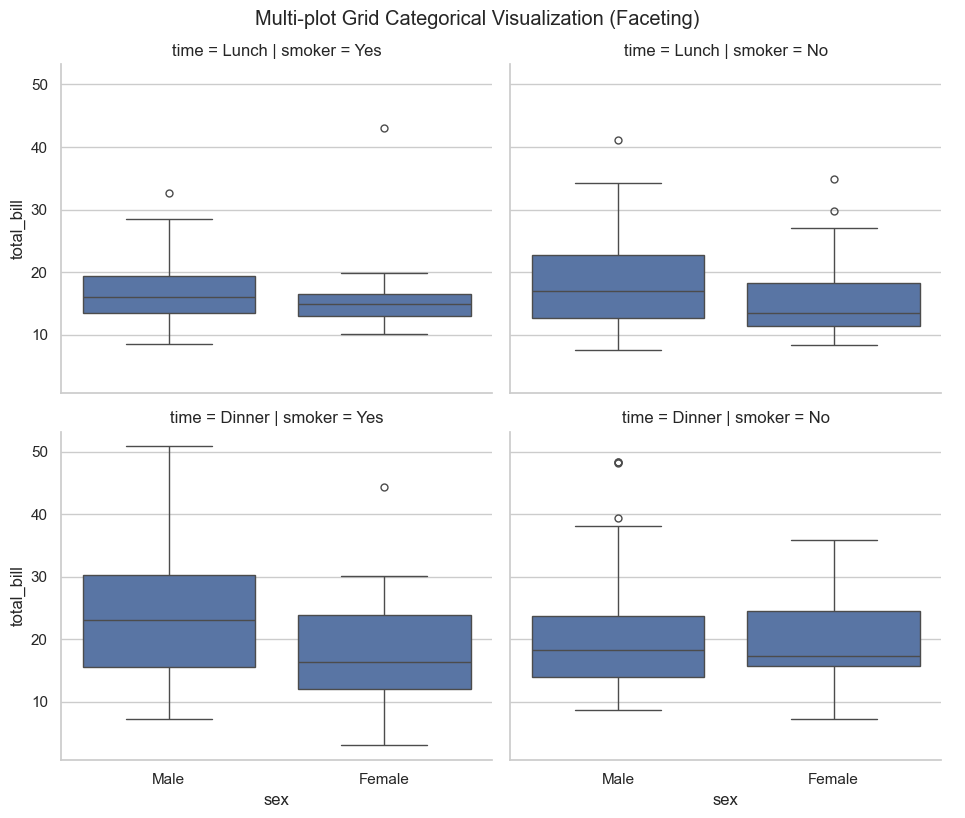

In [23]:
# Faceting with catplot (Multi-plot Grid)
# Using `col` and `row` to create a grid of plots based on categorical variables
sns.catplot(data=tips, x='sex', y='total_bill', kind='box', col='smoker', row='time', height=4, aspect=1.2)
plt.suptitle('Multi-plot Grid Categorical Visualization (Faceting)', y=1.02)
plt.show()


## Part 2: Regression Plots

Seaborn provides functions for visualizing linear relationships:
- **`regplot()`**: Axes-level function for drawing scatterplots with regression lines.
- **`lmplot()`**: Figure-level function for regression plots across a multi-plot grid.

In their simplest invocation, both functions draw a scatterplot of two variables, x and y, and then fit the regression model `y ~ x` and plot the resulting regression line and a 95% confidence interval for that regression.


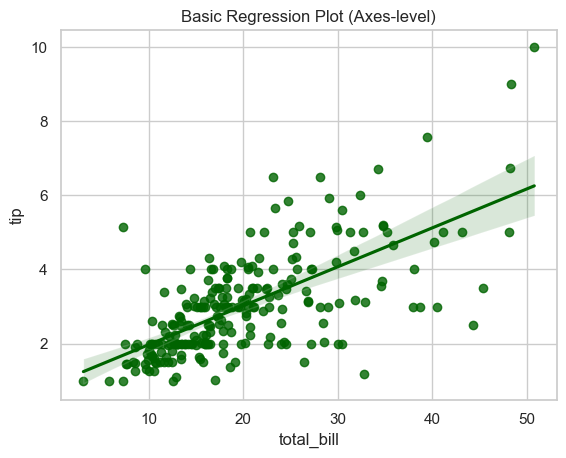

In [24]:
# Basic Regression Plot Using `sns.regplot`
# Note: hue parameter is not directly available in `sns.regplot`
sns.regplot(data=tips, x='total_bill', y='tip', color='darkgreen', marker='o')
plt.title('Basic Regression Plot (Axes-level)')
plt.show()


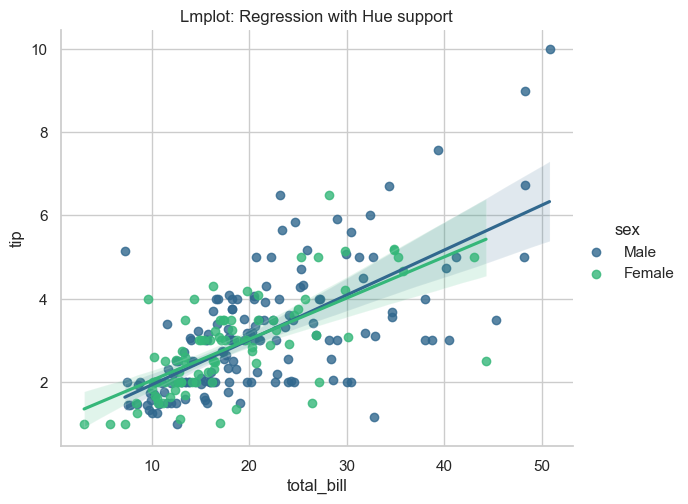

In [25]:
# Figure-level Regression Plot with `sns.lmplot`
# Offers the `hue` parameter and multi-plot grid capability
sns.lmplot(data=tips, x='total_bill', y='tip', hue='sex', palette='viridis', aspect=1.2)
plt.title('Lmplot: Regression with Hue support')
plt.show()


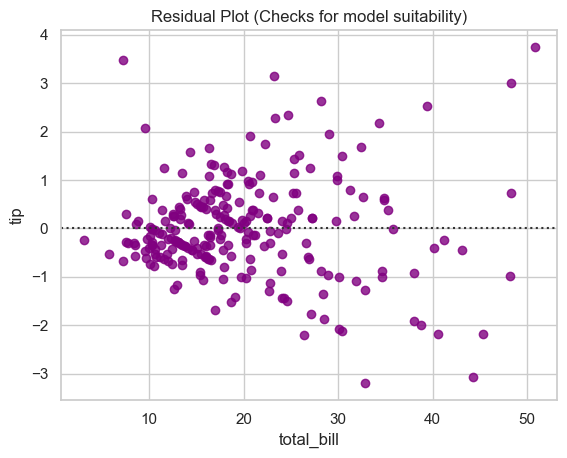

In [26]:
# Residual Plot: Check if our model is correct
# Used for checking the assumptions of linear regression
sns.residplot(data=tips, x='total_bill', y='tip', color='purple')
plt.title('Residual Plot (Checks for model suitability)')
plt.show()


## Part 3: Complex Multi-plot Grids (Facet plots)

Seaborn provides two ways to create complex multi-plot grids:
1. **`catplot`, `relplot`, `displot`, `lmplot`**: High-level figure functions for most common visual situations. No additional mapping required.
2. **`FacetGrid`, `PairGrid`, `JointGrid`**: These allow for more customization by manually mapping plotting functions to the grid.


### 3.1 FacetGrid
`FacetGrid` is used to visualize the distribution of a variable or the relationship between multiple variables separately within subsets of your dataset.


C:\Users\gaura\AppData\Local\Temp\ipykernel_19288\2183777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=tips, x='sex', y='total_bill', kind='violin', col='day', row='time', height=4, palette='Pastel1')


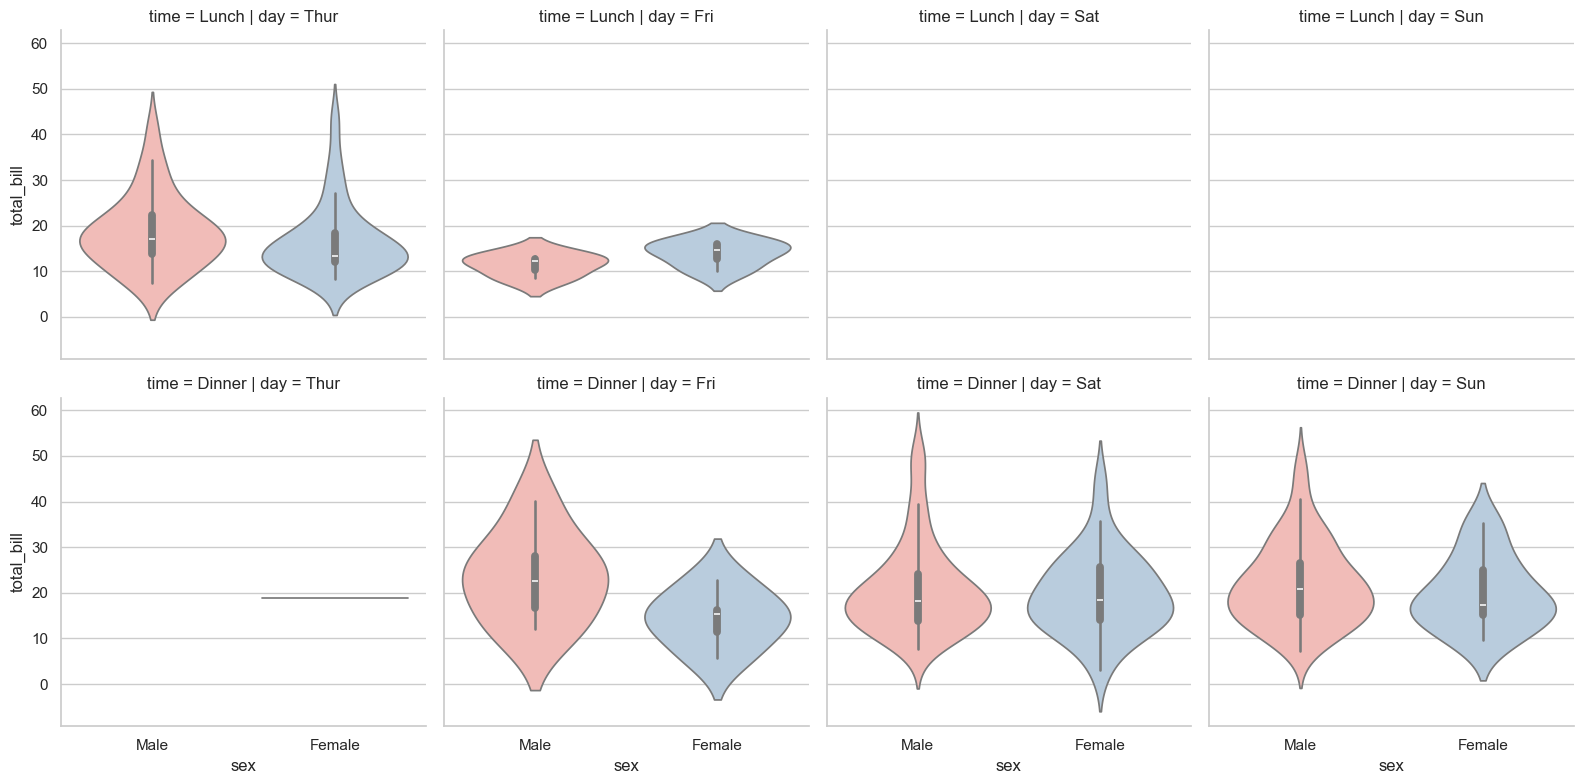

In [27]:
# High-level Faceting using catplot
# Automatically handles the grid creation and plotting
sns.catplot(data=tips, x='sex', y='total_bill', kind='violin', col='day', row='time', height=4, palette='Pastel1')
plt.show()


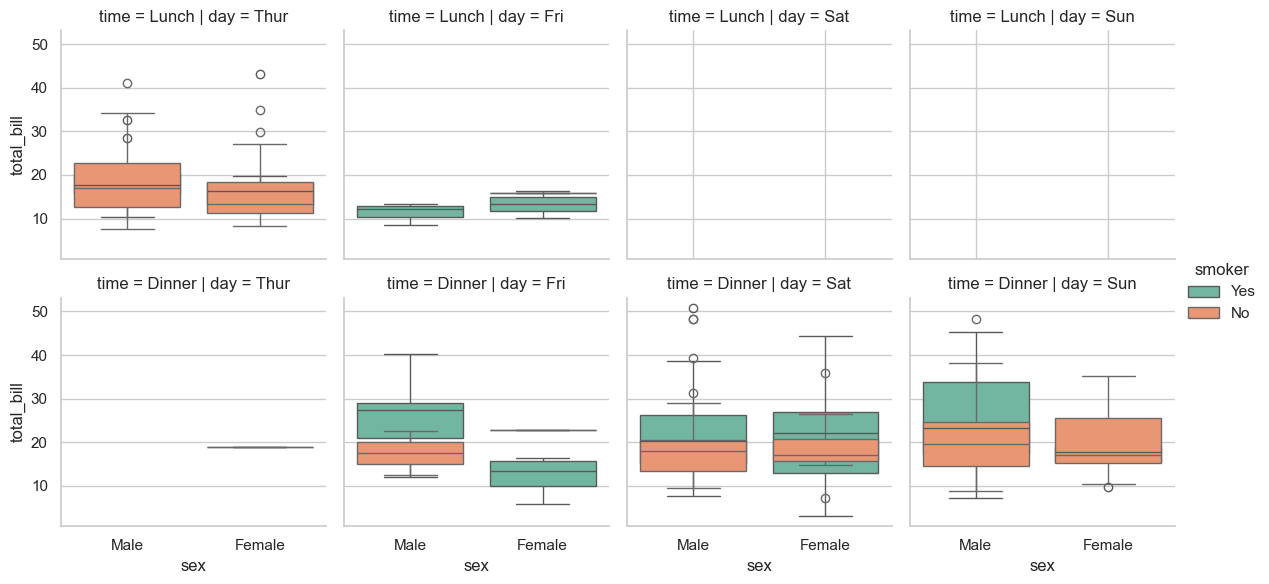

In [28]:
# Manual Faceting using FacetGrid
# 1. Initialize the grid
g = sns.FacetGrid(data=tips, col='day', row='time', hue='smoker', palette='Set2')

# 2. Map a plotting function to the grid
g.map(sns.boxplot, 'sex', 'total_bill', order=['Male', 'Female'])

# 3. Add a legend and display
g.add_legend()
plt.show()


c:\Users\gaura\anaconda3\envs\lamvoy\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\gaura\anaconda3\envs\lamvoy\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\gaura\anaconda3\envs\lamvoy\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\gaura\anaconda3\envs\lamvoy\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


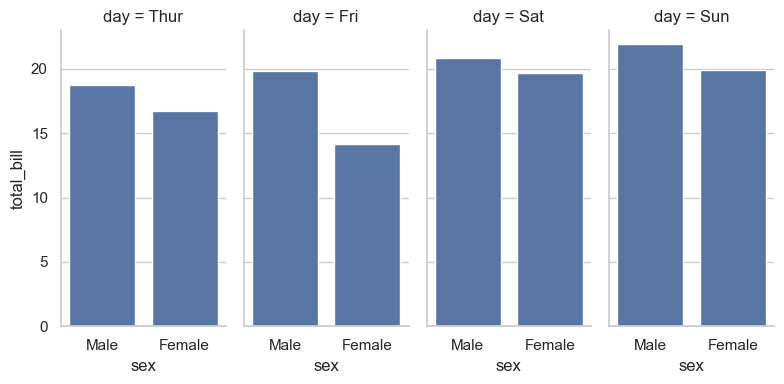

In [29]:
# Adjusting Layout in FacetGrid: Height and Aspect
# height controls the size of each subplot, aspect controls the width-to-height ratio
g = sns.FacetGrid(tips, col="day", height=4, aspect=0.5)
g.map(sns.barplot, "sex", "total_bill", order=['Male', 'Female'], ci=None)
plt.show()


### 3.2 Pairwise Relationships (Pairplot vs PairGrid)
- **`pairplot()`**: Draws a grid of scatterplots for every pair of variables in your dataset.
- **`PairGrid()`**: Allows you to customize the subplots (e.g., histograms on the diagonal and scatterplots on the upper triangle).


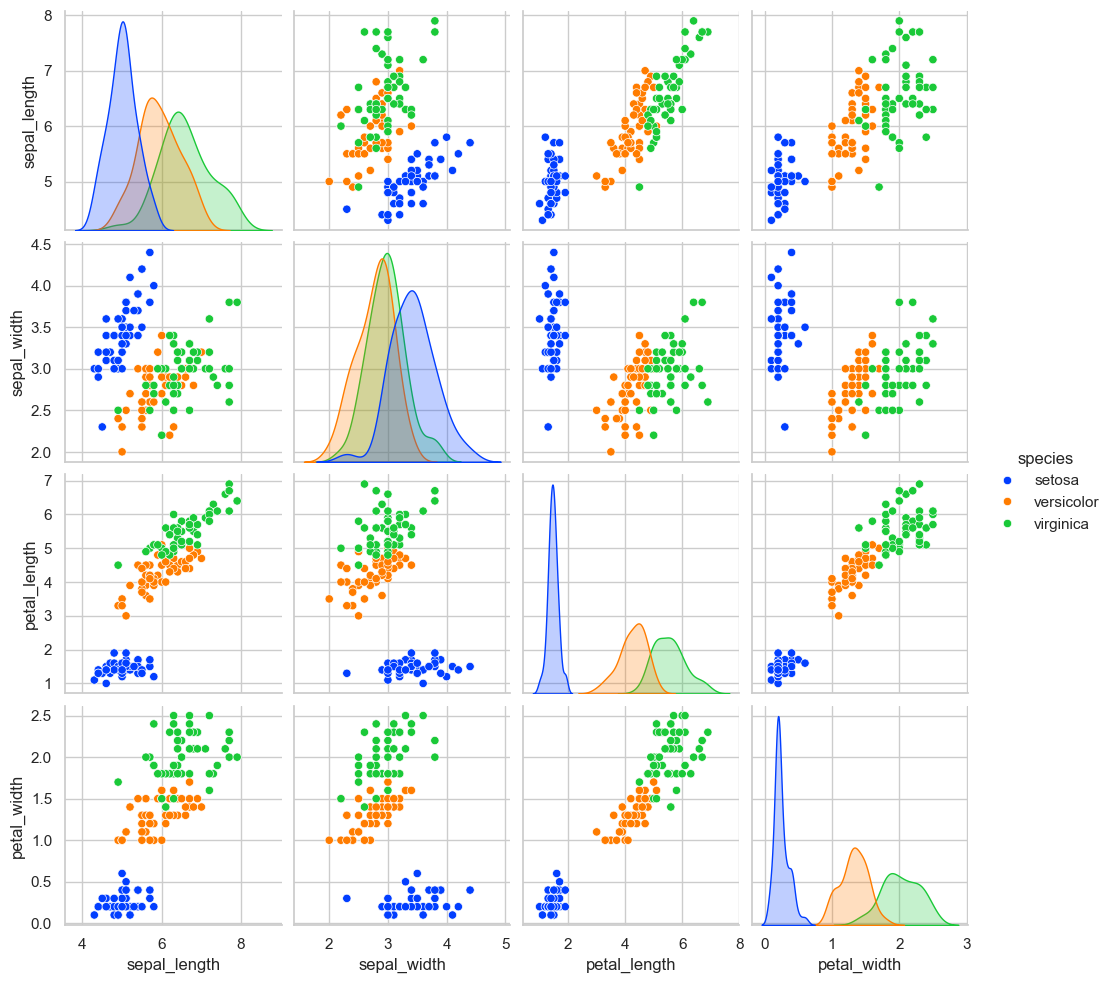

In [37]:
# Global Pairplot: Quick overview of correlations
# Automatically detects all numerical features in the dataframe
sns.pairplot(iris, hue='species', palette='bright')
plt.show()


### Plotting Pairwise Relationship (PairGrid Vs Pairplot)
Using `PairGrid` for complete control over the diagonal, upper, and lower halves of the matrix.


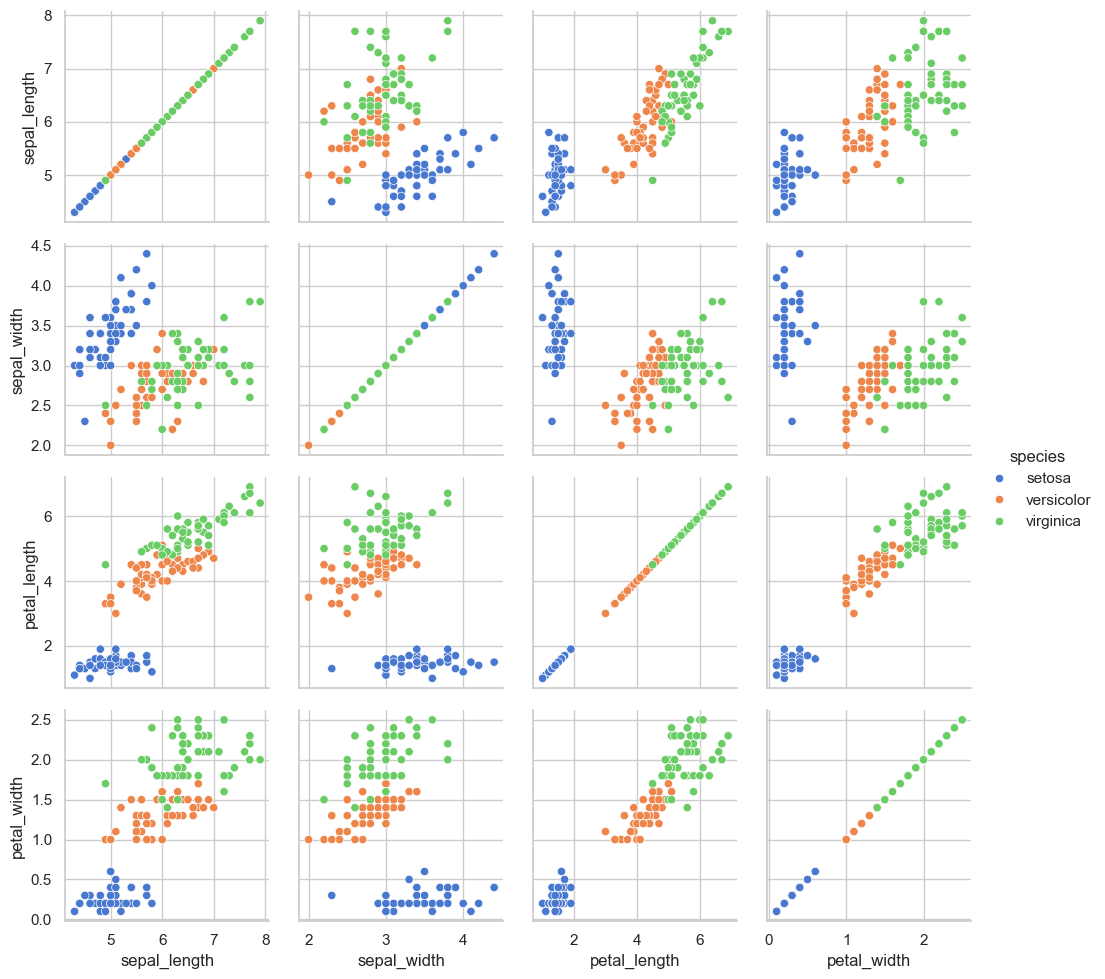

In [38]:
# 3.2.1 Customizing PairGrid
g = sns.PairGrid(data=iris, hue='species', palette='muted')

# 1. Map same plot to all cells
g.map(sns.scatterplot)
g.add_legend()
plt.show()


### 3.2.2 Mapping to Subsets of the Grid
We can use `map_diag` (diagonal), `map_upper` (upper triangle), and `map_lower` (lower triangle) for granular control.


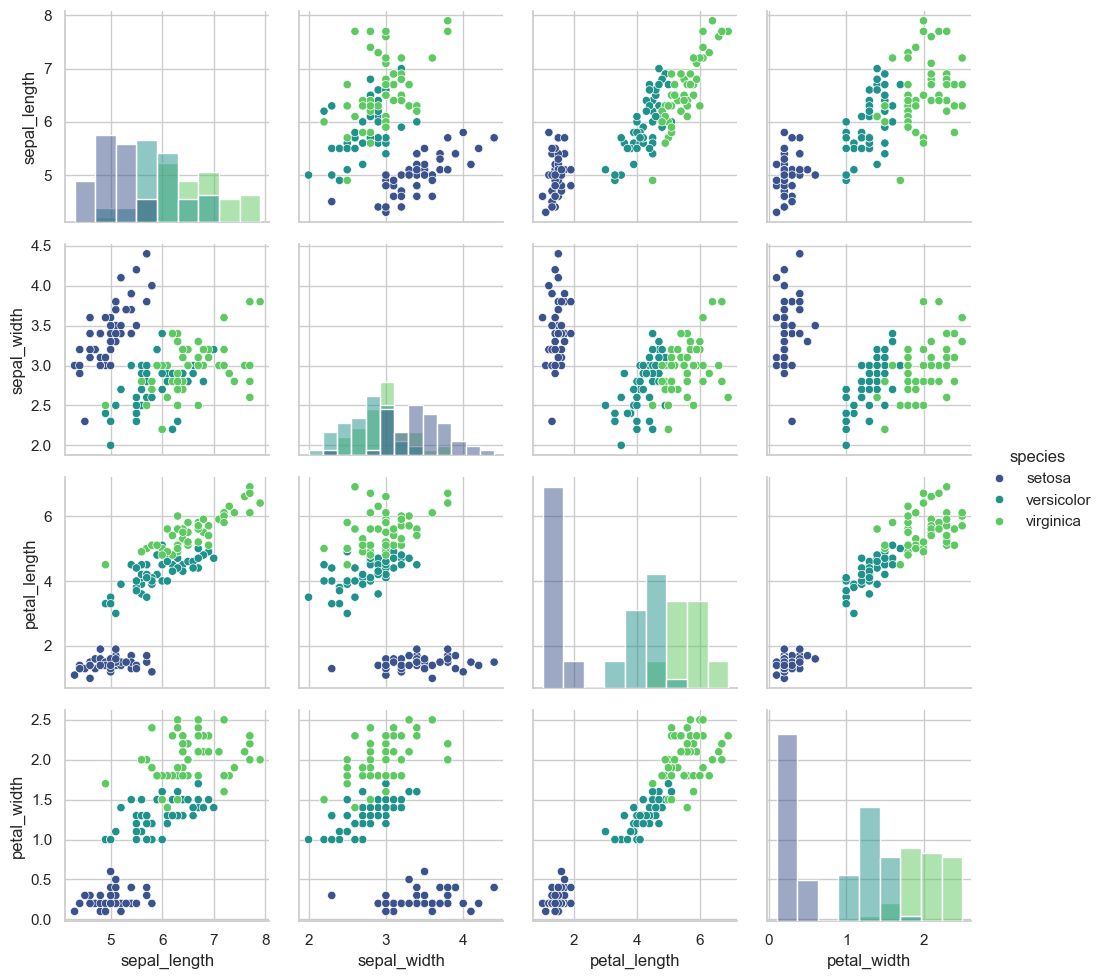

In [39]:
# Customizing Diagonal and Off-diagonal
g = sns.PairGrid(data=iris, hue='species', palette='viridis')
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.show()


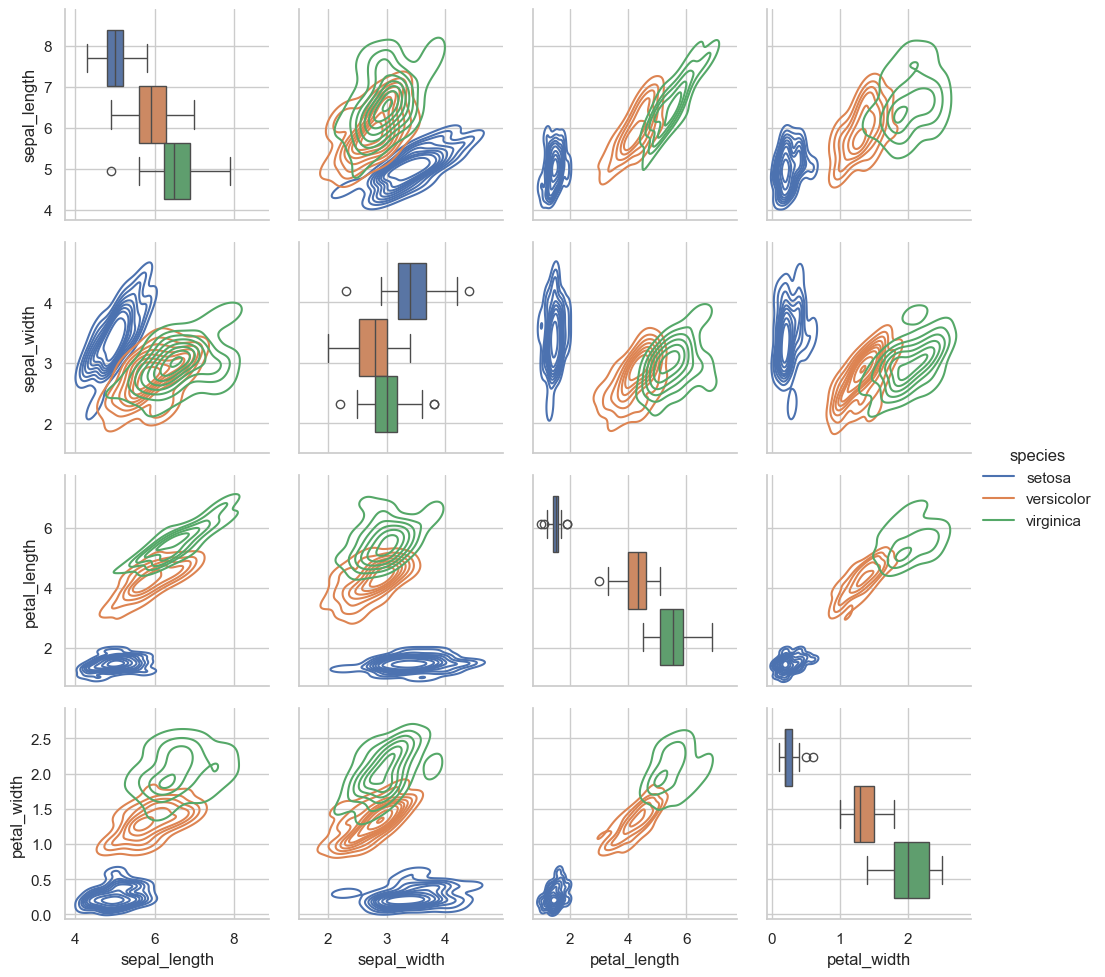

In [40]:
# High-level customization for Lower and Upper triangles
g = sns.PairGrid(data=iris, hue='species')
g.map_diag(sns.boxplot)
g.map_offdiag(sns.kdeplot)
g.add_legend()
plt.show()


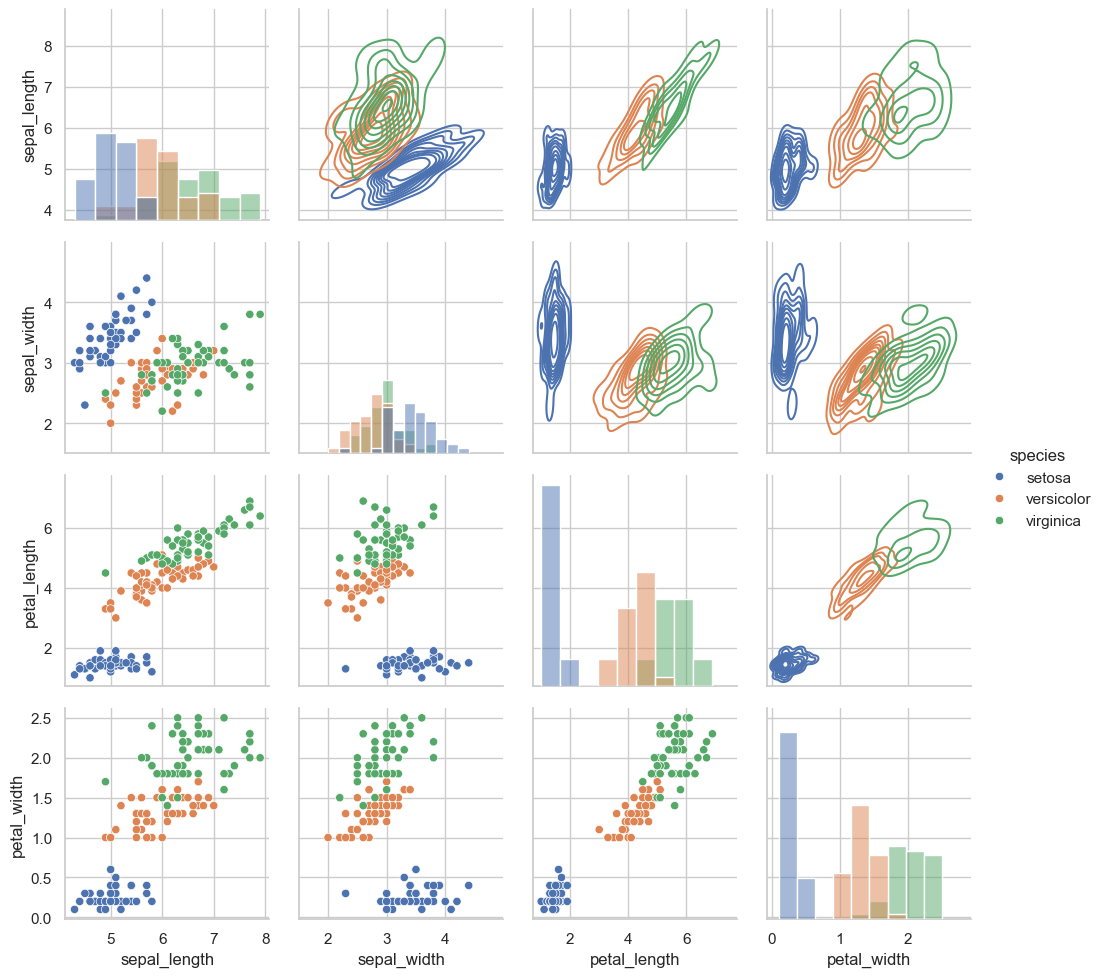

In [41]:
# Using Diagonal, Upper, and Lower methods
g = sns.PairGrid(data=iris, hue='species')
g.map_diag(sns.histplot)
g.map_upper(sns.kdeplot)
g.map_lower(sns.scatterplot)
g.add_legend()
plt.show()


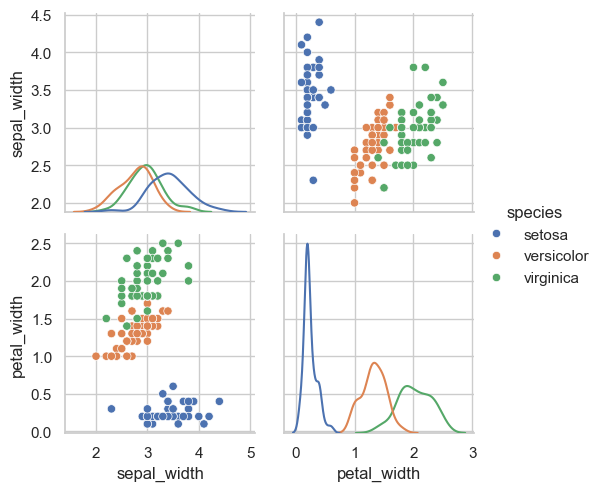

In [42]:
# Selecting Specific Variables using 'vars'
# This limits the Grid to only columns of interest
g = sns.PairGrid(data=iris, hue='species', vars=['sepal_width', 'petal_width'])
g.map_diag(sns.kdeplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.show()


### 3.3 JointGrid vs Jointplot
- **`jointplot()`**: Quickly combines a bivariate plot and marginal distributions.
- **`JointGrid()`**: An object-oriented approach for building a joint plot with more control.


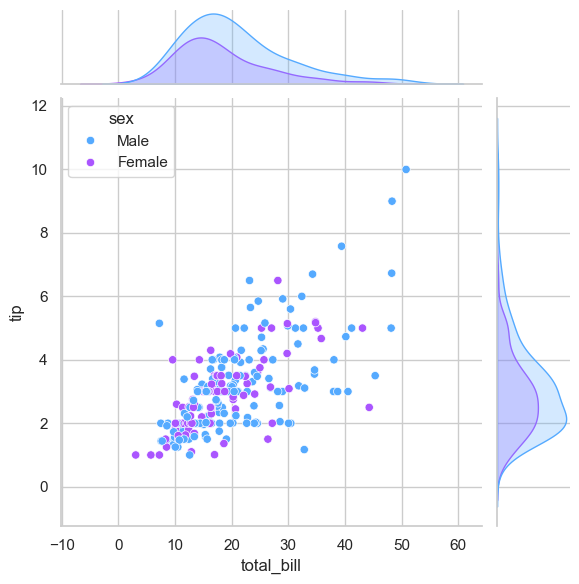

In [43]:
# High-level Jointplot
# Note: kind='hex' does not support the 'hue' parameter.
# If you want to use 'hue', use kind='scatter' or kind='kde'.
sns.jointplot(data=tips, x='total_bill', y='tip', kind='scatter', hue='sex', palette='cool')
plt.show()


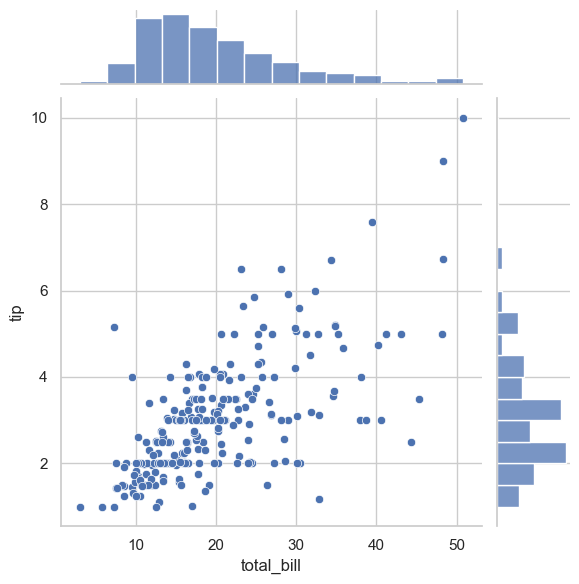

In [44]:
# Manual JointGrid Construction
# 1. Initialize JointGrid
g = sns.JointGrid(data=tips, x='total_bill', y='tip')

# 2. Map plots to the center and marginal axes
g.plot(sns.scatterplot, sns.histplot)
plt.show()


## Part 4: Utility Functions & Dataset Inspection

Seaborn comes with several utility functions to list and load built-in datasets for experimentation.


In [45]:
# 4.1 Listing all available datasets in Seaborn
# This is useful when you want to find more data for practice
print("Available Seaborn Datasets:")
print(sns.get_dataset_names())


Available Seaborn Datasets:
['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


## Summary
In this notebook, we've explored:
- Advanced categorical visualization including **stripplots**, **swarmplots**, **boxplots**, and **violin plots**.
- Estimating central tendency with **barplots** and **pointplots**.
- Statistical relationships through **regression plots** (`regplot`, `lmplot`, `residplot`).
- Complex multi-plot objects using **FacetGrid**, **PairGrid**, and **JointGrid**.
- Using **built-in datasets** and **custom Pandas DataFrames** for visualization.
